# Dashboard ENIGH 2022 — Encuesta Nacional de Ingresos y Gastos de los Hogares
**Fuente:** INEGI — Instituto Nacional de Estadística y Geografía  
**Año de la información:** 2022 — Tercer Trimestre (agosto–noviembre)  
**Universo:** Hogares mexicanos a nivel nacional
**Autor:** Los más guapos de la clase de miss Diana (obviamente Manuel Díaz Rojo, Alejandro Chavez Garcia, Ruben Siloé Reyes Vallejo)

---
Dashboards
1. Estructura del gasto por grandes rubros
2. Composición del ingreso por fuente
3. Disparidades regionales del gasto

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SECCIÓN 0 — Importaciones y configuración global
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Rutas ────────────────────────────────────────────────────────────────────
BASE = '/home/s11o/Projects/School/BigData/BigDataMainAct'

GASTO_DIR   = os.path.join(BASE, 'conjunto_de_datos_gastoshogar_enigh2022_ns')
INGRESO_DIR = os.path.join(BASE, 'conjunto_de_datos_ingresos_enigh2022_ns')

GASTO_CSV   = os.path.join(GASTO_DIR,   'conjunto_de_datos', 'conjunto_de_datos_gastoshogar_enigh2022_ns.csv')
INGRESO_CSV = os.path.join(INGRESO_DIR, 'conjunto_de_datos', 'conjunto_de_datos_ingresos_enigh2022_ns.csv')

CAT_GASTO_DIR   = os.path.join(GASTO_DIR,   'catalogos')
CAT_INGRESO_DIR = os.path.join(INGRESO_DIR, 'catalogos')

OUTPUT_DIR = BASE  # PNGs se guardan junto al notebook

# ── Parámetros de procesamiento ───────────────────────────────────────────────
CHUNK_SIZE = 100_000

# ── Estilo visual ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

PALETTE = [
    '#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
    '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',
    '#aec7e8','#ffbb78','#98df8a','#ff9896','#c5b0d5',
]

# ── Mapeo letras → categorías de gasto ───────────────────────────────────────
LETRAS_GASTO = {
    'A': 'Alimentos y bebidas',
    'B': 'Transporte urbano',
    'C': 'Limpieza del hogar',
    'D': 'Cuidado personal',
    'E': 'Educación',
    'F': 'Comunicaciones',
    'G': 'Vivienda',
    'R': 'Energía y servicios',
    'H': 'Vestido y calzado',
    'I': 'Utensilios del hogar',
    'J': 'Salud',
    'K': 'Enseres domésticos',
    'L': 'Esparcimiento',
    'M': 'Transporte foráneo',
    'N': 'Servicios profesionales',
}

print('✓ Configuración cargada')
print(f'  Gastos  CSV : {GASTO_CSV}')
print(f'  Ingresos CSV: {INGRESO_CSV}')

✓ Configuración cargada
  Gastos  CSV : /home/s11o/Projects/School/BigData/BigDataMainAct/conjunto_de_datos_gastoshogar_enigh2022_ns/conjunto_de_datos/conjunto_de_datos_gastoshogar_enigh2022_ns.csv
  Ingresos CSV: /home/s11o/Projects/School/BigData/BigDataMainAct/conjunto_de_datos_ingresos_enigh2022_ns/conjunto_de_datos/conjunto_de_datos_ingresos_enigh2022_ns.csv


## Sección 1 — Carga de catálogos

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SECCIÓN 1 — Catálogos
# ─────────────────────────────────────────────────────────────────────────────

def leer_catalogo(path, key_col, val_col='descripcion', encoding='latin-1', key_type=None):
    """Lee un catálogo CSV y devuelve un dict {clave: descripcion}."""
    df = pd.read_csv(path, encoding=encoding)
    df.columns = df.columns.str.strip()
    df[val_col] = df[val_col].str.strip()
    if key_type:
        df[key_col] = df[key_col].astype(key_type)
    return dict(zip(df[key_col], df[val_col]))

# Catálogos de gastos
cat_gastos    = leer_catalogo(os.path.join(CAT_GASTO_DIR, 'gastos.csv'),      'gastos')
cat_tipo      = leer_catalogo(os.path.join(CAT_GASTO_DIR, 'tipo_gasto.csv'),  'tipo_gasto')
cat_forma_pag = leer_catalogo(os.path.join(CAT_GASTO_DIR, 'forma_pag.csv'),   'forma_pag')
cat_lugar     = leer_catalogo(os.path.join(CAT_GASTO_DIR, 'lugar_comp.csv'),  'lugar_comp', key_type=int)
cat_orga      = leer_catalogo(os.path.join(CAT_GASTO_DIR, 'orga_inst.csv'),   'orga_inst',  key_type=int)
cat_entidad   = leer_catalogo(os.path.join(CAT_GASTO_DIR, 'entidad.csv'),     'entidad',    key_type=int)
cat_inst_salud= leer_catalogo(os.path.join(CAT_GASTO_DIR, 'inst_salud.csv'),  'inst_salud', key_type=int)

# Catálogo de ingresos
cat_ingresos  = leer_catalogo(os.path.join(CAT_INGRESO_DIR, 'ingresos_cat.csv'), 'ingresos_cat')

# Verificación
print(f'cat_gastos      : {len(cat_gastos):>4} claves')
print(f'cat_tipo        : {len(cat_tipo):>4} claves')
print(f'cat_forma_pag   : {len(cat_forma_pag):>4} claves')
print(f'cat_lugar       : {len(cat_lugar):>4} claves')
print(f'cat_orga        : {len(cat_orga):>4} claves')
print(f'cat_entidad     : {len(cat_entidad):>4} claves  ← debe ser 32')
print(f'cat_inst_salud  : {len(cat_inst_salud):>4} claves')
print(f'cat_ingresos    : {len(cat_ingresos):>4} claves')

cat_gastos      :  745 claves
cat_tipo        :    7 claves
cat_forma_pag   :   11 claves
cat_lugar       :   19 claves
cat_orga        :   10 claves
cat_entidad     :   32 claves  ← debe ser 32
cat_inst_salud  :   13 claves
cat_ingresos    :   83 claves


## Sección 2 — Carga de datos

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2.1 — Ingresos (carga completa, ~34 MB)
# ─────────────────────────────────────────────────────────────────────────────
print('Cargando archivo de ingresos...')

df_ing = pd.read_csv(
    INGRESO_CSV,
    encoding='utf-8-sig',
    dtype={
        'clave'  : 'category',
        'entidad': 'int8',
        'factor' : 'float32',
    },
)

# Columnas de ingreso mensual → numérico
for col in ['ing_1','ing_2','ing_3','ing_4','ing_5','ing_6','ing_tri']:
    if col in df_ing.columns:
        df_ing[col] = pd.to_numeric(df_ing[col], errors='coerce')

df_ing['ingreso_pond'] = df_ing['ing_tri'] * df_ing['factor']

print(f'✓ Ingresos cargados: {df_ing.shape[0]:,} filas × {df_ing.shape[1]} columnas')
print(f'  NaN en ingreso_pond: {df_ing["ingreso_pond"].isna().sum():,}')
print(f'  Columnas: {list(df_ing.columns)}')

Cargando archivo de ingresos...
✓ Ingresos cargados: 397,182 filas × 22 columnas
  NaN en ingreso_pond: 0
  Columnas: ['folioviv', 'foliohog', 'numren', 'clave', 'mes_1', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'ing_1', 'ing_2', 'ing_3', 'ing_4', 'ing_5', 'ing_6', 'ing_tri', 'entidad', 'est_dis', 'upm', 'factor', 'ingreso_pond']


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2.2 — Gastos: lectura por chunks (~526 MB, ~5 M filas)
#   Se leen sólo 10 de 31 columnas → ahorro de ~67 % de RAM por chunk
#   Se acumulan 6 agregaciones; cada una tiene sólo cientos de filas
# ─────────────────────────────────────────────────────────────────────────────
USECOLS = [
    'clave', 'tipo_gasto', 'forma_pag1', 'lugar_comp',
    'orga_inst', 'inst_1', 'entidad', 'factor', 'gasto_tri', 'mes_dia'
]

# Solo floats en DTYPE_MAP — columnas de texto como str, enteros sin dtype
# para evitar fallos cuando hay NaN (int no admite NaN; se convierte en el loop)
DTYPE_MAP = {
    'clave'     : 'str',
    'tipo_gasto': 'str',
    'forma_pag1': 'str',
    'lugar_comp': 'str',
    'orga_inst' : 'str',
    'inst_1'    : 'str',
    'factor'    : 'float32',
    'gasto_tri' : 'float32',
}

# Acumuladores intermedios (listas de DataFrames parciales)
acc_letra_entidad = []
acc_tipo_gasto    = []
acc_forma_pag     = []
acc_lugar         = []
acc_salud         = []
acc_mes_letra     = []

print(f'Iniciando lectura por chunks (tamaño = {CHUNK_SIZE:,})...')
chunk_num = 0

reader = pd.read_csv(
    GASTO_CSV,
    encoding='utf-8-sig',
    usecols=USECOLS,
    dtype=DTYPE_MAP,
    chunksize=CHUNK_SIZE,
    na_values=['', ' '],
)

for chunk in reader:
    chunk_num += 1
    if chunk_num % 10 == 0:
        print(f'  Chunk {chunk_num:>3}  filas acum. ≈ {chunk_num * CHUNK_SIZE:>10,}')

    # ── Conversión explícita de enteros (soporta NaN) ─────────────────────
    chunk['entidad'] = pd.to_numeric(chunk['entidad'], errors='coerce').fillna(0).astype('int8')
    chunk['mes_dia'] = pd.to_numeric(chunk['mes_dia'], errors='coerce').fillna(0).astype('int32')

    # ── Campos derivados ──────────────────────────────────────────────────
    chunk['gasto_tri']  = pd.to_numeric(chunk['gasto_tri'], errors='coerce').fillna(0).astype('float32')
    chunk['factor']     = pd.to_numeric(chunk['factor'],    errors='coerce').fillna(0).astype('float32')
    chunk['gasto_pond'] = chunk['gasto_tri'] * chunk['factor']
    chunk['clave_letra']= chunk['clave'].str[0]
    chunk['mes_num']    = (chunk['mes_dia'] // 100).astype('int8')

    # ── Agrupaciones parciales ────────────────────────────────────────────

    # D1 y D3: gasto ponderado por letra × entidad
    g1 = chunk.groupby(['clave_letra', 'entidad'], observed=True)['gasto_pond'].sum()
    acc_letra_entidad.append(g1)

    # D10: tipo de gasto (monetario vs no-monetario)
    g2 = chunk.groupby('tipo_gasto', observed=True)['gasto_pond'].sum()
    acc_tipo_gasto.append(g2)

    # D4: forma de pago
    g3 = chunk.groupby('forma_pag1', observed=True)['gasto_pond'].sum()
    acc_forma_pag.append(g3)

    # D5: lugar de compra
    g4 = chunk.groupby('lugar_comp', observed=True)['gasto_pond'].sum()
    acc_lugar.append(g4)

    # D6: gasto en salud (claves J*)
    mask_salud = chunk['clave_letra'] == 'J'
    if mask_salud.any():
        g5 = chunk.loc[mask_salud].groupby('inst_1', observed=True)['gasto_pond'].sum()
        acc_salud.append(g5)

    # D8: estacionalidad mes × letra
    g6 = chunk.groupby(['mes_num', 'clave_letra'], observed=True)['gasto_pond'].sum()
    acc_mes_letra.append(g6)

# ── Consolidar acumuladores ───────────────────────────────────────────────────
print('\nConsolidando acumuladores...')

df_letra_entidad = (
    pd.concat(acc_letra_entidad)
    .groupby(level=[0,1]).sum()
    .reset_index()
)
df_tipo_gasto = (
    pd.concat(acc_tipo_gasto)
    .groupby(level=0).sum()
    .reset_index()
)
df_forma_pag = (
    pd.concat(acc_forma_pag)
    .groupby(level=0).sum()
    .reset_index()
)
df_lugar = (
    pd.concat(acc_lugar)
    .groupby(level=0).sum()
    .reset_index()
)
df_salud = (
    pd.concat(acc_salud)
    .groupby(level=0).sum()
    .reset_index()
)
df_mes_letra = (
    pd.concat(acc_mes_letra)
    .groupby(level=[0,1]).sum()
    .reset_index()
)

# Liberar memoria
del acc_letra_entidad, acc_tipo_gasto, acc_forma_pag
del acc_lugar, acc_salud, acc_mes_letra

print('\n✓ Datos consolidados')
print(f'  df_letra_entidad : {df_letra_entidad.shape}')
print(f'  df_tipo_gasto    : {df_tipo_gasto.shape}')
print(f'  df_forma_pag     : {df_forma_pag.shape}')
print(f'  df_lugar         : {df_lugar.shape}')
print(f'  df_salud         : {df_salud.shape}')
print(f'  df_mes_letra     : {df_mes_letra.shape}')

Iniciando lectura por chunks (tamaño = 100,000)...
  Chunk  10  filas acum. ≈  1,000,000
  Chunk  20  filas acum. ≈  2,000,000
  Chunk  30  filas acum. ≈  3,000,000
  Chunk  40  filas acum. ≈  4,000,000
  Chunk  50  filas acum. ≈  5,000,000

Consolidando acumuladores...

✓ Datos consolidados
  df_letra_entidad : (533, 3)
  df_tipo_gasto    : (6, 2)
  df_forma_pag     : (11, 2)
  df_lugar         : (19, 2)
  df_salud         : (13, 2)
  df_mes_letra     : (24, 3)


## Sección 3 — Dashboard 1: Estructura del Gasto por Grandes Rubros

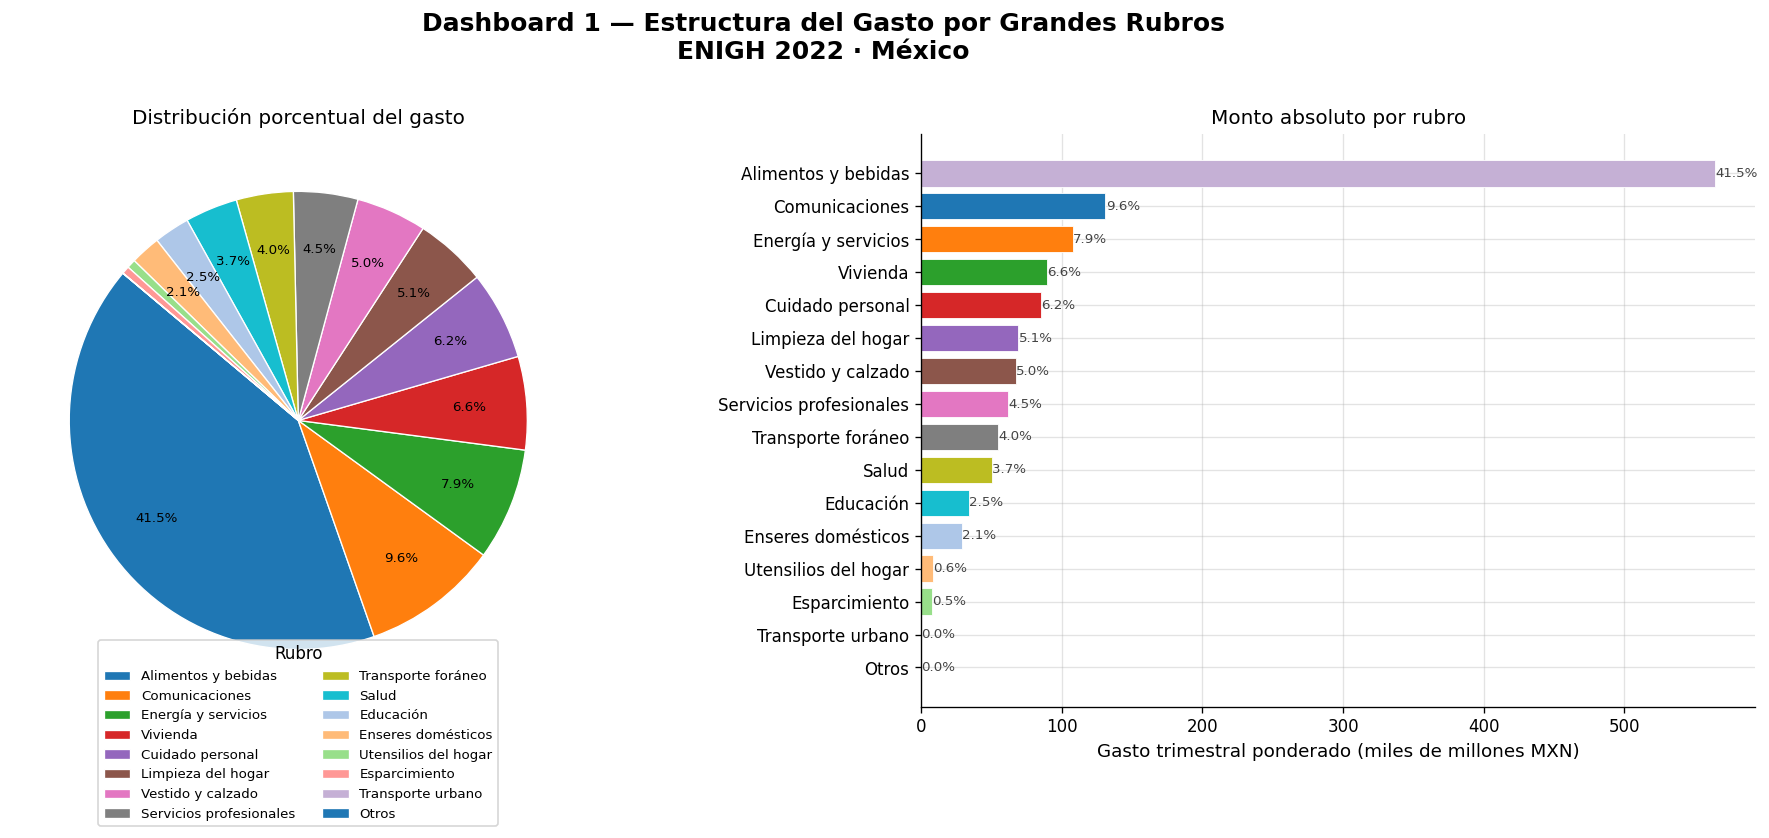

✓ Guardado: /home/s11o/Projects/School/BigData/BigDataMainAct/d1_estructura_gasto.png


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# DASHBOARD 1 — Estructura del gasto por grandes rubros
# ─────────────────────────────────────────────────────────────────────────────

# Agrupar por letra (excluir 'T' = totales)
d1 = (
    df_letra_entidad[df_letra_entidad['clave_letra'] != 'T']
    .groupby('clave_letra')['gasto_pond']
    .sum()
    .reset_index()
)
d1['categoria'] = d1['clave_letra'].map(LETRAS_GASTO).fillna('Otros')
d1 = d1.groupby('categoria')['gasto_pond'].sum().reset_index()
d1 = d1.sort_values('gasto_pond', ascending=False)
d1['pct'] = d1['gasto_pond'] / d1['gasto_pond'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Dashboard 1 — Estructura del Gasto por Grandes Rubros\nENIGH 2022 · México',
             fontsize=15, fontweight='bold', y=1.01)

# ── Pie chart ────────────────────────────────────────────────────────────────
ax0 = axes[0]
wedges, texts, autotexts = ax0.pie(
    d1['gasto_pond'],
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    colors=PALETTE[:len(d1)],
    startangle=140,
    wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'},
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(8)
ax0.legend(
    wedges, d1['categoria'],
    title='Rubro', loc='lower center',
    bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=8
)
ax0.set_title('Distribución porcentual del gasto', fontsize=12)

# ── Barras horizontales ───────────────────────────────────────────────────────
ax1 = axes[1]
bars = ax1.barh(
    d1['categoria'][::-1],
    d1['gasto_pond'][::-1] / 1e9,
    color=PALETTE[:len(d1)][::-1],
    edgecolor='white', linewidth=0.5,
)
for bar, pct in zip(bars, d1['pct'][::-1]):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', va='center', fontsize=8, color='#444')
ax1.set_xlabel('Gasto trimestral ponderado (miles de millones MXN)')
ax1.set_title('Monto absoluto por rubro', fontsize=12)
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))
ax1.set_axisbelow(True)

plt.tight_layout()
out1 = os.path.join(OUTPUT_DIR, 'd1_estructura_gasto.png')
plt.savefig(out1, bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Guardado: {out1}')

## Sección 4 — Dashboard 2: Composición del Ingreso por Fuente

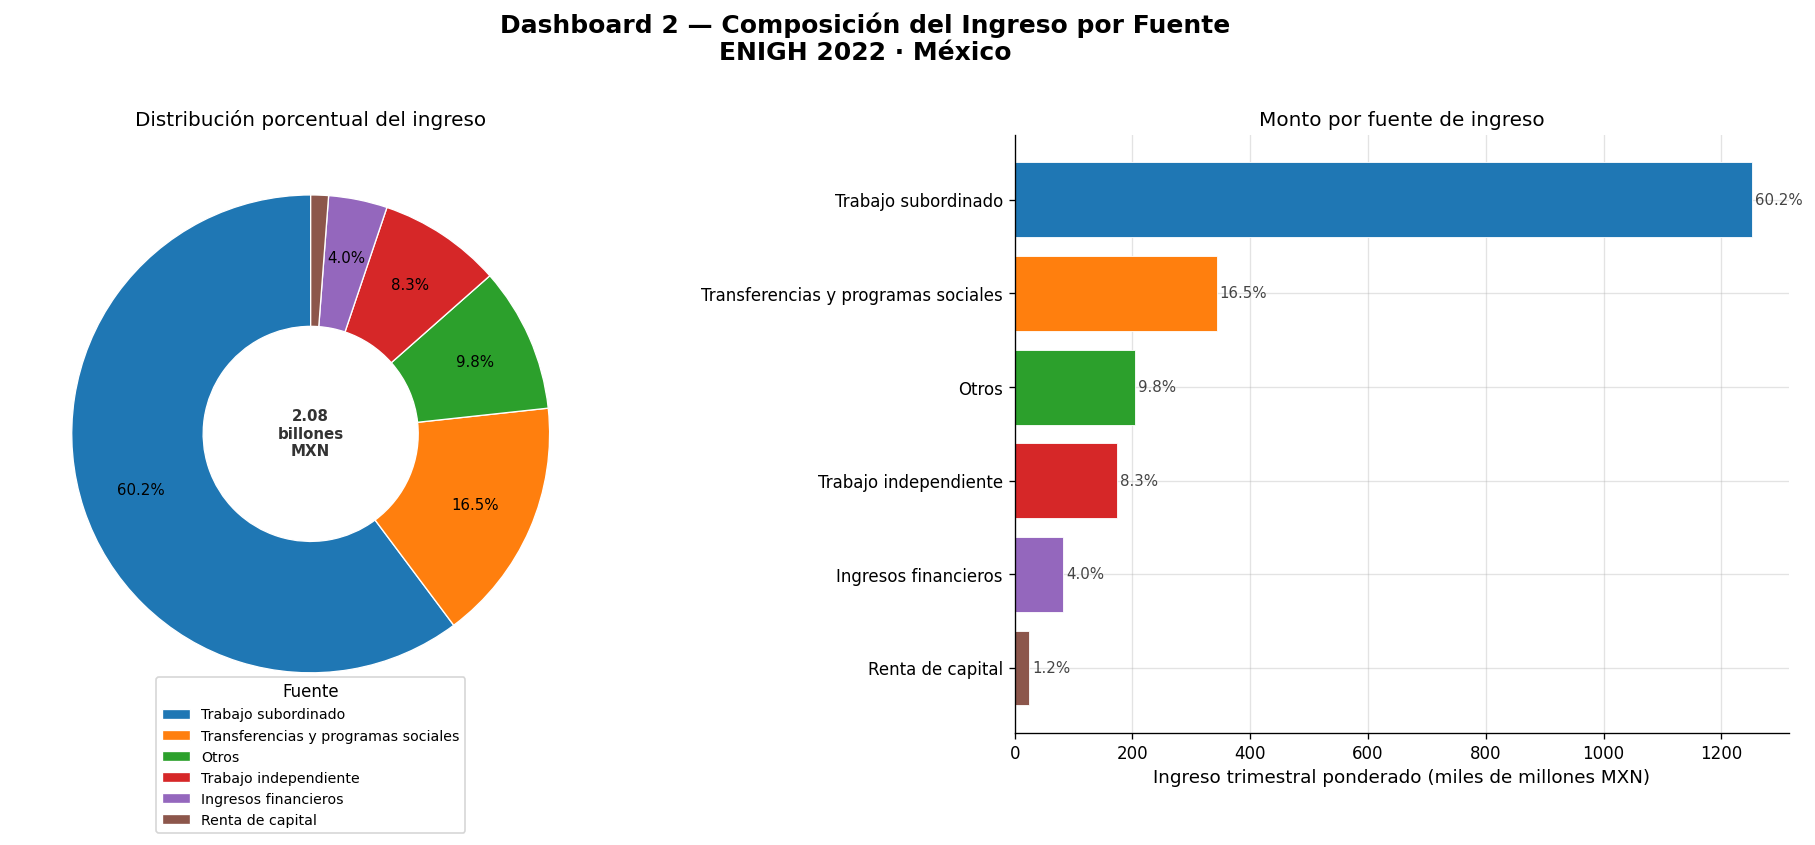

✓ Guardado: /home/s11o/Projects/School/BigData/BigDataMainAct/d2_composicion_ingreso.png


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# DASHBOARD 2 — Composición del ingreso por fuente
# ─────────────────────────────────────────────────────────────────────────────

def clasificar_ingreso(clave):
    """Agrupa claves P### en 5 categorías de fuente de ingreso."""
    try:
        num = int(str(clave)[1:])
    except (ValueError, TypeError):
        return 'Otros'
    if   1  <= num <= 9:   return 'Trabajo subordinado'
    elif 10 <= num <= 22:  return 'Trabajo independiente'
    elif 23 <= num <= 31:  return 'Renta de capital'
    elif (32 <= num <= 48) or (101 <= num <= 108):
                           return 'Transferencias y programas sociales'
    elif 49 <= num <= 66:  return 'Ingresos financieros'
    else:                  return 'Otros'

df_ing2 = df_ing.copy()
df_ing2['fuente'] = df_ing2['clave'].astype(str).apply(clasificar_ingreso)
d2 = (
    df_ing2.groupby('fuente')['ingreso_pond']
    .sum()
    .reset_index()
    .sort_values('ingreso_pond', ascending=False)
)
d2['pct'] = d2['ingreso_pond'] / d2['ingreso_pond'].sum() * 100
del df_ing2

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Dashboard 2 — Composición del Ingreso por Fuente\nENIGH 2022 · México',
             fontsize=15, fontweight='bold', y=1.01)

# ── Donut chart ───────────────────────────────────────────────────────────────
ax0 = axes[0]
wedges, texts, autotexts = ax0.pie(
    d2['ingreso_pond'],
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 1.5 else '',
    colors=PALETTE[:len(d2)],
    startangle=90,
    wedgeprops={'width': 0.55, 'linewidth': 0.8, 'edgecolor': 'white'},
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(9)
ax0.legend(
    wedges, d2['fuente'],
    title='Fuente', loc='lower center',
    bbox_to_anchor=(0.5, -0.18), ncol=1, fontsize=8.5
)
total_ing = d2['ingreso_pond'].sum()
ax0.text(0, 0, f'{total_ing/1e12:.2f}\nbillones\nMXN',
         ha='center', va='center', fontsize=9, fontweight='bold', color='#333')
ax0.set_title('Distribución porcentual del ingreso', fontsize=12)

# ── Barras ────────────────────────────────────────────────────────────────────
ax1 = axes[1]
bars = ax1.barh(
    d2['fuente'][::-1],
    d2['ingreso_pond'][::-1] / 1e9,
    color=PALETTE[:len(d2)][::-1],
    edgecolor='white', linewidth=0.5,
)
for bar, pct in zip(bars, d2['pct'][::-1]):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', va='center', fontsize=9, color='#444')
ax1.set_xlabel('Ingreso trimestral ponderado (miles de millones MXN)')
ax1.set_title('Monto por fuente de ingreso', fontsize=12)
ax1.set_axisbelow(True)

plt.tight_layout()
out2 = os.path.join(OUTPUT_DIR, 'd2_composicion_ingreso.png')
plt.savefig(out2, bbox_inches='tight', dpi=150)
plt.show()
print(f'✓ Guardado: {out2}')